# 🛡️ Cyber Attack Detection using Big Data Analytics  
### 🔍 Using Classification & Anomaly Detection on NSL-KDD Dataset  

---

## 👨‍💻 Project Overview  
This project focuses on detecting cyber attacks in network traffic using Big Data Analytics techniques.  
We use the NSL-KDD dataset, an improved version of the KDD'99 dataset, to build intelligent models that classify and detect anomalies in network connections.

---

## 🚀 Technologies Used  
- Python  
- PySpark (Big Data Processing)  
- Scikit-learn (Machine Learning)  
- Jupyter Notebook  

---

## 🎯 Objectives  
- Detect malicious network traffic  
- Classify normal vs attack connections  
- Identify unknown attacks using anomaly detection  
- Handle large-scale data using distributed computing  

---

## 🧠 Key Concepts  
- Classification (Supervised Learning)  
- Anomaly Detection (Unsupervised Learning)  
- Clustering (KMeans)  
- Feature Engineering & Selection  

---

## 📂 Dataset  
We use the NSL-KDD dataset, which includes:  
- Normal network traffic  
- Multiple types of cyber attacks (DoS, Probe, R2L, U2R)  

---

## 📚 Contents  

1. 📝 Task Description Summary  
2. ⚡ Data Loading using PySpark  
3. 🔍 Exploratory Data Analysis (EDA)  
4. 🔄 One-Hot Encoding for Categorical Variables  
5. 🎯 Feature Selection using Attribute Ratio  
6. 📏 Data Preparation & Standardization  
7. 📉 Visualization using PCA  
8. 🚨 KMeans Clustering for Anomaly Detection + Random Forest  
9. 🤖 Supervised Classification for Attack Detection  
10. 📊 Results Summary  

---

## NSL-KDD Dataset Description

The NSL-KDD dataset is a benchmark dataset used for network intrusion detection. It is an improved version of the KDD'99 dataset and is designed to overcome its limitations such as redundancy and bias. The dataset contains network connection records, where each record is described by 41 features representing various aspects of network traffic.

Each record is labeled as either normal or an attack. The attacks are categorized into four main types: Denial of Service (DoS), Probe, Remote to Local (R2L), and User to Root (U2R). This dataset is widely used in machine learning for classification and anomaly detection tasks in cybersecurity.

The NSL-KDD dataset has several advantages over the original KDD dataset:
- It does not include redundant records in the training set, reducing bias.
- There are no duplicate records in the test set, ensuring fair evaluation.
- The dataset is balanced, allowing better comparison of different models.
- The size of the dataset is reasonable, making it suitable for complete analysis.

Overall, the NSL-KDD dataset provides a reliable platform for building and evaluating intrusion detection systems.

## 1. Task description summary



The objective of this project is to detect cyber attacks in network traffic using Big Data Analytics.  
It involves classification and anomaly detection techniques to identify malicious activities.

## 2. Data loading

In [1]:
# Here are some imports that are used along this notebook
import os
import math
import itertools
import multiprocessing
import pandas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
from collections import OrderedDict
%matplotlib inline
gt0 = time()

In [2]:
from pyspark import SparkConf, SparkContext
from pyspark.sql import SQLContext, Row

In [3]:
import pandas as pd

path = "NSL_KDD_Dataset/"

df1 = pd.read_csv(path + "KDDTrain+.txt", header=None)
df2 = pd.read_csv(path + "KDDTest+.txt", header=None)
df3 = pd.read_csv(path + "KDDTrain+_20Percent.txt", header=None)

df = pd.concat([df1, df2, df3], ignore_index=True)

print("Rows after combining:", len(df))

target = 1000000

df_big = pd.concat([df] * (target // len(df) + 1), ignore_index=True)
df_big = df_big.iloc[:target]

print("Final rows:", len(df_big))

# Save back
df_big.to_csv(path + "KDDTrain+.txt", index=False, header=False)

print("✅ 10 lakh dataset created successfully!")

Rows after combining: 1047736
Final rows: 1000000
✅ 10 lakh dataset created successfully!


In [4]:
conf = SparkConf()\
    .setMaster(f"local[{multiprocessing.cpu_count()}]")\
    .setAppName("PySpark NSL-KDD")\
    .setAll([("spark.driver.memory", "4g"), ("spark.default.parallelism", f"{multiprocessing.cpu_count()}")])

# Creating local SparkContext with specified SparkConf and creating SQLContext based on it
sc = SparkContext.getOrCreate(conf=conf)
sc.setLogLevel('INFO')
sqlContext = SQLContext(sc)

/usr/local/spark/python/pyspark/sql/context.py:113: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(


In [5]:
from pyspark.sql.types import *
from pyspark.sql.functions import udf, split, col
import pyspark.sql.functions as sql

train20_nsl_kdd_dataset_path = os.path.join("NSL_KDD_Dataset", "KDDTrain+_20Percent.txt")
train_nsl_kdd_dataset_path = os.path.join("NSL_KDD_Dataset", "KDDTrain+.txt")
test_nsl_kdd_dataset_path = os.path.join("NSL_KDD_Dataset", "KDDTest+.txt")

col_names = np.array(["duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","labels"])

nominal_inx = [1, 2, 3]
binary_inx = [6, 11, 13, 14, 20, 21]
numeric_inx = list(set(range(41)).difference(nominal_inx).difference(binary_inx))

nominal_cols = col_names[nominal_inx].tolist()
binary_cols = col_names[binary_inx].tolist()
numeric_cols = col_names[numeric_inx].tolist()

In [6]:
# Function to load dataset and divide it into 8 partitions
def load_dataset(path):
    dataset_rdd = sc.textFile(path, 8).map(lambda line: line.split(','))
    dataset_df = (dataset_rdd.toDF(col_names.tolist()).select(
                    col('duration').cast(DoubleType()),
                    col('protocol_type').cast(StringType()),
                    col('service').cast(StringType()),
                    col('flag').cast(StringType()),
                    col('src_bytes').cast(DoubleType()),
                    col('dst_bytes').cast(DoubleType()),
                    col('land').cast(DoubleType()),
                    col('wrong_fragment').cast(DoubleType()),
                    col('urgent').cast(DoubleType()),
                    col('hot').cast(DoubleType()),
                    col('num_failed_logins').cast(DoubleType()),
                    col('logged_in').cast(DoubleType()),
                    col('num_compromised').cast(DoubleType()),
                    col('root_shell').cast(DoubleType()),
                    col('su_attempted').cast(DoubleType()),
                    col('num_root').cast(DoubleType()),
                    col('num_file_creations').cast(DoubleType()),
                    col('num_shells').cast(DoubleType()),
                    col('num_access_files').cast(DoubleType()),
                    col('num_outbound_cmds').cast(DoubleType()),
                    col('is_host_login').cast(DoubleType()),
                    col('is_guest_login').cast(DoubleType()),
                    col('count').cast(DoubleType()),
                    col('srv_count').cast(DoubleType()),
                    col('serror_rate').cast(DoubleType()),
                    col('srv_serror_rate').cast(DoubleType()),
                    col('rerror_rate').cast(DoubleType()),
                    col('srv_rerror_rate').cast(DoubleType()),
                    col('same_srv_rate').cast(DoubleType()),
                    col('diff_srv_rate').cast(DoubleType()),
                    col('srv_diff_host_rate').cast(DoubleType()),
                    col('dst_host_count').cast(DoubleType()),
                    col('dst_host_srv_count').cast(DoubleType()),
                    col('dst_host_same_srv_rate').cast(DoubleType()),
                    col('dst_host_diff_srv_rate').cast(DoubleType()),
                    col('dst_host_same_src_port_rate').cast(DoubleType()),
                    col('dst_host_srv_diff_host_rate').cast(DoubleType()),
                    col('dst_host_serror_rate').cast(DoubleType()),
                    col('dst_host_srv_serror_rate').cast(DoubleType()),
                    col('dst_host_rerror_rate').cast(DoubleType()),
                    col('dst_host_srv_rerror_rate').cast(DoubleType()),
                    col('labels').cast(StringType())))

    return dataset_df

The first part of data preparation is deviding connections into normal and attack classes based on 'labels' column. Then attacks are splitted to four main categories: DoS, Probe, R2L and U2R. After this, all of those categories are indexed. Also, ID column is added to simplify work with clustered data.

In [7]:
from pyspark.ml import Pipeline, Transformer
from pyspark.ml.feature import StringIndexer
from pyspark import keyword_only
from pyspark.ml.param.shared import HasInputCol, HasOutputCol, Param

# Dictionary that contains mapping of various attacks to the four main categories
attack_dict = {
    'normal': 'normal',
    
    'back': 'DoS',
    'land': 'DoS',
    'neptune': 'DoS',
    'pod': 'DoS',
    'smurf': 'DoS',
    'teardrop': 'DoS',
    'mailbomb': 'DoS',
    'apache2': 'DoS',
    'processtable': 'DoS',
    'udpstorm': 'DoS',
    
    'ipsweep': 'Probe',
    'nmap': 'Probe',
    'portsweep': 'Probe',
    'satan': 'Probe',
    'mscan': 'Probe',
    'saint': 'Probe',

    'ftp_write': 'R2L',
    'guess_passwd': 'R2L',
    'imap': 'R2L',
    'multihop': 'R2L',
    'phf': 'R2L',
    'spy': 'R2L',
    'warezclient': 'R2L',
    'warezmaster': 'R2L',
    'sendmail': 'R2L',
    'named': 'R2L',
    'snmpgetattack': 'R2L',
    'snmpguess': 'R2L',
    'xlock': 'R2L',
    'xsnoop': 'R2L',
    'worm': 'R2L',
    
    'buffer_overflow': 'U2R',
    'loadmodule': 'U2R',
    'perl': 'U2R',
    'rootkit': 'U2R',
    'httptunnel': 'U2R',
    'ps': 'U2R',    
    'sqlattack': 'U2R',
    'xterm': 'U2R'
}

attack_mapping_udf = udf(lambda v: attack_dict[v])

class Labels2Converter(Transformer):

    @keyword_only
    def __init__(self):
        super(Labels2Converter, self).__init__()

    def _transform(self, dataset):
        return dataset.withColumn('labels2', sql.regexp_replace(col('labels'), '^(?!normal).*$', 'attack'))
     
class Labels5Converter(Transformer):
    
    @keyword_only
    def __init__(self):
        super(Labels5Converter, self).__init__()

    def _transform(self, dataset):
        return dataset.withColumn('labels5', attack_mapping_udf(col('labels')))
    
labels2_indexer = StringIndexer(inputCol="labels2", outputCol="labels2_index")
labels5_indexer = StringIndexer(inputCol="labels5", outputCol="labels5_index")

labels_mapping_pipeline = Pipeline(stages=[Labels2Converter(), Labels5Converter(), labels2_indexer, labels5_indexer])

labels2 = ['normal', 'attack']
labels5 = ['normal', 'DoS', 'Probe', 'R2L', 'U2R']
labels_col = 'labels2_index'

In [8]:
# Loading train data
t0 = time()
train_df = load_dataset(train_nsl_kdd_dataset_path)

# Fitting preparation pipeline
labels_mapping_model = labels_mapping_pipeline.fit(train_df)

# Transforming labels column and adding id column
train_df = labels_mapping_model.transform(train_df).withColumn('id', sql.monotonically_increasing_id())

train_df = train_df.cache()
print(f"Number of examples in train set: {train_df.count()}")
print(f"Time: {time() - t0:.2f}s")

Number of examples in train set: 1000000
Time: 35.83s


In [9]:
# Loading test data
t0 = time()
test_df = load_dataset(test_nsl_kdd_dataset_path)

# Transforming labels column and adding id column
test_df = labels_mapping_model.transform(test_df).withColumn('id', sql.monotonically_increasing_id())

test_df = test_df.cache()
print(f"Number of examples in test set: {test_df.count()}")
print(f"Time: {time() - t0:.2f}s")

Number of examples in test set: 22544
Time: 2.03s


## 3. Exploratory Data Analysis

Here are some descriptive statistics of available features.

In [10]:
# Labels columns
(train_df.groupby('labels2').count().show())
(train_df.groupby('labels5').count().sort(sql.desc('count')).show())

+-------+------+
|labels2| count|
+-------+------+
| normal|522189|
| attack|477811|
+-------+------+

+-------+------+
|labels5| count|
+-------+------+
| normal|522189|
|    DoS|360871|
|  Probe| 94078|
|    R2L| 21441|
|    U2R|  1421|
+-------+------+



In [11]:
(test_df.groupby('labels2').count().show())
(test_df.groupby('labels5').count().sort(sql.desc('count')).show())

+-------+-----+
|labels2|count|
+-------+-----+
| normal| 9711|
| attack|12833|
+-------+-----+

+-------+-----+
|labels5|count|
+-------+-----+
| normal| 9711|
|    DoS| 7458|
|    R2L| 2754|
|  Probe| 2421|
|    U2R|  200|
+-------+-----+



In [12]:
# 'protocol_type' nominal column
(train_df.crosstab(nominal_cols[0], 'labels2').sort(sql.asc(nominal_cols[0] + '_labels2')).show())
(train_df.crosstab(nominal_cols[0], 'labels5').sort(sql.asc(nominal_cols[0] + '_labels5')).show())

+---------------------+------+------+
|protocol_type_labels2|attack|normal|
+---------------------+------+------+
|                 icmp| 53866|  9647|
|                  tcp|401634|416110|
|                  udp| 22311| 96432|
+---------------------+------+------+

+---------------------+------+-----+-----+----+------+
|protocol_type_labels5|   DoS|Probe|  R2L| U2R|normal|
+---------------------+------+-----+-----+----+------+
|                 icmp| 23643|30201|   22|   0|  9647|
|                  tcp|330864|50652|18720|1398|416110|
|                  udp|  6364|13225| 2699|  23| 96432|
+---------------------+------+-----+-----+----+------+



In [13]:
# 'service' nominal column
print(train_df.select(nominal_cols[1]).distinct().count())
(train_df.crosstab(nominal_cols[1], 'labels2').sort(sql.asc(nominal_cols[1] + '_labels2')).show(n=70))
(train_df.crosstab(nominal_cols[1], 'labels5').sort(sql.asc(nominal_cols[1] + '_labels5')).show(n=70))

70
+---------------+------+------+
|service_labels2|attack|normal|
+---------------+------+------+
|            IRC|    21|  1371|
|            X11|   109|   518|
|         Z39_50|  6270|     0|
|            aol|    12|     0|
|           auth|  5305|  1721|
|            bgp|  5228|     0|
|        courier|  5439|     0|
|       csnet_ns|  4001|     0|
|            ctf|  4225|     0|
|        daytime|  3806|     0|
|        discard|  3891|     0|
|         domain|  3950|   273|
|       domain_u|    79| 67956|
|           echo|  3119|     0|
|          eco_i| 29849|  3587|
|          ecr_i| 23912|  1577|
|            efs|  3631|     0|
|           exec|  3442|     0|
|         finger|  9044|  4106|
|            ftp|  9234|  6641|
|       ftp_data| 16001| 36598|
|         gopher|  3835|     0|
|        harvest|    12|     0|
|      hostnames|  3360|     0|
|           http| 22110|301068|
|      http_2784|     6|     0|
|       http_443|  3936|     0|
|      http_8001|    17|     0|
|    

In [14]:
# 'flag' nominal column
print(train_df.select(nominal_cols[2]).distinct().count())
(train_df.crosstab(nominal_cols[2], 'labels2').sort(sql.asc(nominal_cols[2] + '_labels2')).show())
(train_df.crosstab(nominal_cols[2], 'labels5').sort(sql.asc(nominal_cols[2] + '_labels5')).show())

11
+------------+------+------+
|flag_labels2|attack|normal|
+------------+------+------+
|         OTH|   250|    71|
|         REJ| 79761| 18912|
|        RSTO| 13405|  1545|
|      RSTOS0|   729|     5|
|        RSTR| 19270|  1248|
|          S0|252173|  2524|
|          S1|    87|  2654|
|          S2|   106|   840|
|          S3|  1309|   365|
|          SF|108505|494013|
|          SH|  2216|    12|
+------------+------+------+

+------------+------+-----+-----+---+------+
|flag_labels5|   DoS|Probe|  R2L|U2R|normal|
+------------+------+-----+-----+---+------+
|         OTH|     0|  250|    0|  0|    71|
|         REJ| 54215|24956|   16|574| 18912|
|        RSTO| 10462| 2464|  473|  6|  1545|
|      RSTOS0|     0|  729|    0|  0|     5|
|        RSTR|  3454|15764|   42| 10|  1248|
|          S0|249866| 2307|    0|  0|  2524|
|          S1|    23|   27|   37|  0|  2654|
|          S2|    78|   17|   11|  0|   840|
|          S3|  1264|    6|   39|  0|   365|
|          SF| 41509|

In [15]:
# Binary columns
(train_df.select(binary_cols).describe().toPandas().transpose())

,0,1,2,3,4
summary,count,mean,stddev,min,max
land,1000000,1.96E-4,0.013998634932084598,0.0,1.0
logged_in,1000000,0.401068,0.49011498608867266,0.0,1.0
root_shell,1000000,0.001498,0.03867502413389673,0.0,1.0
su_attempted,1000000,0.001036,0.04353077760537469,0.0,2.0
is_host_login,1000000,6.2E-5,0.00787376771286899,0.0,1.0
is_guest_login,1000000,0.011628,0.10720448268986325,0.0,1.0


In [16]:
# 'su_attempted' should be a binary feature, but has 3 values
(train_df.crosstab('su_attempted', 'labels2').show())

+--------------------+------+------+
|su_attempted_labels2|attack|normal|
+--------------------+------+------+
|                 1.0|    11|   165|
|                 0.0|477800|521594|
|                 2.0|     0|   430|
+--------------------+------+------+



In [17]:
# '2.0' value is replaced to '0.0' for both train and test datasets
train_df = train_df.replace(2.0, 0.0, 'su_attempted')
test_df = test_df.replace(2.0, 0.0, 'su_attempted')

In [18]:
# Numeric columns
print(len(numeric_cols))
(train_df.select(numeric_cols).describe().toPandas().transpose())

32


,0,1,2,3,4
summary,count,mean,stddev,min,max
duration,1000000,281.459266,2504.72231592658,0.0,57715.0
src_bytes,1000000,38710.833742,5177259.330115174,0.0,1.379963888E9
dst_bytes,1000000,15631.334084,3496193.996122893,0.0,1.309937401E9
wrong_fragment,1000000,0.021128,0.24396652871996072,0.0,3.0
urgent,1000000,1.72E-4,0.017719219225765234,0.0,3.0
hot,1000000,0.191853,2.0440292572384067,0.0,101.0
num_failed_logins,1000000,0.003631,0.06721473318269121,0.0,5.0
num_compromised,1000000,0.254187,21.290573906251698,0.0,7479.0
num_root,1000000,0.273719,21.78140609186399,0.0,7468.0


In [19]:
(train_df.crosstab('num_outbound_cmds', 'labels2').show())

+-------------------------+------+------+
|num_outbound_cmds_labels2|attack|normal|
+-------------------------+------+------+
|                      0.0|477811|522189|
+-------------------------+------+------+



As 'num_outbound_cmds' feature takes only 0.0 values, so it is dropped as redundant.

In [20]:
train_df = train_df.drop('num_outbound_cmds')
test_df = test_df.drop('num_outbound_cmds')
numeric_cols.remove('num_outbound_cmds')

Commented code below is related to removing highly correlated features. However, it hasen't been tested a lot yet.

In [21]:
# from pyspark.mllib.stat import Statistics
# from pyspark.mllib.linalg import Vectors
# from pyspark.ml.feature import VectorAssembler

# t0 = time()
# stat_assembler = VectorAssembler(
#                 inputCols=numeric_cols,
#                 outputCol='features')

# stat_rdd = stat_assembler.transform(train_df).rdd.map(lambda row: row['features'].toArray())

# pearson_corr = Statistics.corr(stat_rdd, method='pearson')
# spearman_corr = Statistics.corr(stat_rdd, method='spearman')

# print(time() - t0)

In [22]:
# f, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# ax1.set_title("Pearson")
# ax2.set_title("Spearman")
# sns.heatmap(pearson_corr, ax=ax1)
# sns.heatmap(spearman_corr, ax=ax2)

In [23]:
# inx_correlated_to_delete = [8, 15, 28, 17, 29]

# for inx in inx_correlated_to_delete:
#     train_df = train_df.drop(numeric_cols[inx])
#     test_df = test_df.drop(numeric_cols[inx])

# numeric_cols = [col for inx, col in enumerate(numeric_cols) if inx not in inx_correlated_to_delete]

# train_df = train_df.cache()
# test_df = test_df.cache()
# print(train_df.count())
# print(test_df.count())
# print(len(numeric_cols))

## 4. One Hot Encoding for categorical variables

One Hot Encoding (OHE) is used for treating categorical variables. Custom function is created for demonstration purposes. However, it could be easily replaced by PySpark OneHotEncoder.

In [24]:
def ohe_vec(cat_dict, row):
    vec = np.zeros(len(cat_dict))
    vec[cat_dict[row]] = float(1.0)
    return vec.tolist()

def ohe(df, nominal_col):
    categories = (df.select(nominal_col)
                    .distinct()
                    .rdd.map(lambda row: row[0])
                    .collect())
    
    cat_dict = dict(zip(categories, range(len(categories))))
    
    udf_ohe_vec = udf(lambda row: ohe_vec(cat_dict, row), 
                      StructType([StructField(cat, DoubleType(), False) for cat in categories]))
    
    df = df.withColumn(nominal_col + '_ohe', udf_ohe_vec(col(nominal_col))).cache()
    
    nested_cols = [nominal_col + '_ohe.' + cat for cat in categories]
    ohe_cols = [nominal_col + '_' + cat for cat in categories]
        
    for new, old in zip(ohe_cols, nested_cols):
        df = df.withColumn(new, col(old))

    df = df.drop(nominal_col + '_ohe')
                   
    return df, ohe_cols

In [25]:
t0 = time()
train_ohe_cols = []

train_df, train_ohe_col0 = ohe(train_df, nominal_cols[0])
train_ohe_cols += train_ohe_col0

train_df, train_ohe_col1 = ohe(train_df, nominal_cols[1])
train_ohe_cols += train_ohe_col1

train_df, train_ohe_col2 = ohe(train_df, nominal_cols[2])
train_ohe_cols += train_ohe_col2

binary_cols += train_ohe_cols

train_df = train_df.cache()
print(f"Number of examples in train set: {train_df.count()}")
print(f"Time: {time() - t0:.2f}s")

Number of examples in train set: 1000000
Time: 39.69s


Custom list of test binary cols is used as test dataset could contain additional categories for 'service' and 'flag' features. However, those additional categories aren't used below.

In [26]:
t0 = time()
test_ohe_cols = []

test_df, test_ohe_col0_names = ohe(test_df, nominal_cols[0])
test_ohe_cols += test_ohe_col0_names

test_df, test_ohe_col1_names = ohe(test_df, nominal_cols[1])
test_ohe_cols += test_ohe_col1_names

test_df, test_ohe_col2_names = ohe(test_df, nominal_cols[2])
test_ohe_cols += test_ohe_col2_names

test_binary_cols = col_names[binary_inx].tolist() + test_ohe_cols

test_df = test_df.cache()
print(f"Number of examples in test set: {test_df.count()}")
print(f"Time: {time() - t0:.2f}s")

Number of examples in test set: 22544
Time: 5.53s


## 5. Feature Selection using Attribute Ratio

Attribute Ratio approach is used for feature selection purposes. This approach was described by Hee-su Chae and Sang Hyun Choi in [Feature Selection for efficient Intrusion Detection using Attribute Ratio](http://www.naun.org/main/UPress/cc/2014/a102019-106.pdf) and [Feature Selection for Intrusion Detection using NSL-KDD](http://www.wseas.us/e-library/conferences/2013/Nanjing/ACCIS/ACCIS-30.pdf)

This approach is also used for nominal variables as they were encoded as binary variables above.

As it is a possible to have 'null' values because binary features could have Frequency(0) = 0, those 'null' values are replaced with 1000.0 (magic number). For NSL KDD dataset it is related only for 'protocol_type_tcp' ohe variable.

In [27]:
def getAttributeRatio(df, numericCols, binaryCols, labelCol):
    ratio_dict = {}
    
    if numericCols:
        avg_dict = (df
                .select(list(map(lambda c: sql.avg(c).alias(c), numericCols)))
                .first()
                .asDict())

        ratio_dict.update(df
                .groupBy(labelCol)
                .avg(*numericCols)
                .select(list(map(lambda c: sql.max(col('avg(' + c + ')')/avg_dict[c]).alias(c), numericCols)))
                .fillna(0.0)
                .first()
                .asDict())
    
    if binaryCols:
        ratio_dict.update((df
                .groupBy(labelCol)
                .agg(*list(map(lambda c: (sql.sum(col(c))/(sql.count(col(c)) - sql.sum(col(c)))).alias(c), binaryCols)))
                .fillna(1000.0)
                .select(*list(map(lambda c: sql.max(col(c)).alias(c), binaryCols)))
                .first()
                .asDict()))
        
    return OrderedDict(sorted(ratio_dict.items(), key=lambda v: -v[1]))

def selectFeaturesByAR(ar_dict, min_ar):
    return [f for f in ar_dict.keys() if ar_dict[f] >= min_ar]

In [28]:
t0 = time()
ar_dict = getAttributeRatio(train_df, numeric_cols, binary_cols, 'labels5')

print(f"Number of features in Attribute Ration dict: {len(ar_dict)}")
print(f"Time: {time() - t0:.2f}s")
ar_dict

Number of features in Attribute Ration dict: 121
Time: 11.09s


OrderedDict([('urgent', 364.13924029916694),
             ('num_shells', 235.52246260016798),
             ('protocol_type_tcp', 60.78260869565217),
             ('num_file_creations', 38.66584955852814),
             ('num_failed_logins', 36.8646921038437),
             ('flag_SF', 32.139103554868626),
             ('hot', 15.390954058170363),
             ('num_access_files', 11.43994203762701),
             ('num_compromised', 9.166673594966477),
             ('dst_bytes', 8.611845933203332),
             ('num_root', 8.432858655346905),
             ('src_bytes', 7.930506032126717),
             ('duration', 6.458639026741712),
             ('dst_host_srv_diff_host_rate', 5.5476418428588685),
             ('dst_host_diff_srv_rate', 4.859801807286833),
             ('diff_srv_rate', 4.570606274778195),
             ('dst_host_same_src_port_rate', 4.134215911663728),
             ('dst_host_srv_rerror_rate', 3.465391482257628),
             ('srv_rerror_rate', 3.433095753768088),
   

## 6. Data preparation

Standartization is necessary as a lot of distance based algorithms are used below. Custom standartization is created for demonstration purposes, so it could be easily replaced by PySpark StandardScaler. Note that data is sparse, so it is reasonable to not substract mean for avoiding violating sparsity. 

In [29]:
t0 = time()
avg_dict = (train_df.select(list(map(lambda c: sql.avg(c).alias(c), numeric_cols))).first().asDict())
std_dict = (train_df.select(list(map(lambda c: sql.stddev(c).alias(c), numeric_cols))).first().asDict())

def standardizer(column):
    return ((col(column) - avg_dict[column])/std_dict[column]).alias(column)

# Standardizer without mean
# def standardizer(column):
#     return (col(column)/std_dict[column]).alias(column)

train_scaler = [*binary_cols, *list(map(standardizer, numeric_cols)), *['id', 'labels2_index', 'labels2', 'labels5_index', 'labels5']]
test_scaler = [*test_binary_cols, *list(map(standardizer, numeric_cols)), *['id', 'labels2_index', 'labels2', 'labels5_index', 'labels5']]

scaled_train_df = (train_df.select(train_scaler).cache())
scaled_test_df = (test_df.select(test_scaler).cache())

print(scaled_train_df.count())
print(scaled_test_df.count())
print(f"Time: {time() - t0:.2f}s")

1000000
22544
Time: 9.91s


VectorAssembler is used for combining a given list of columns into a single vector column. Then VectorIndexer is used for indexing categorical (binary) features. Indexing categorical features allows algorithms to treat them appropriately, improving performance.

In [30]:
from pyspark.ml.feature import VectorIndexer, VectorAssembler
assembler = VectorAssembler(inputCols=selectFeaturesByAR(ar_dict, 0.01), outputCol='raw_features')
indexer = VectorIndexer(inputCol='raw_features', outputCol='indexed_features', maxCategories=2)

prep_pipeline = Pipeline(stages=[assembler, indexer])
prep_model = prep_pipeline.fit(scaled_train_df)

In [31]:
t0 = time()
scaled_train_df = (prep_model
        .transform(scaled_train_df)
        .select('id', 'indexed_features', 'labels2_index', 'labels2', 'labels5_index', 'labels5')
        .cache())

scaled_test_df = (prep_model 
        .transform(scaled_test_df)
        .select('id', 'indexed_features','labels2_index', 'labels2', 'labels5_index', 'labels5')
        .cache())

print(scaled_train_df.count())
print(scaled_test_df.count())
print(f"Time: {time() - t0:.2f}s")

1000000
22544
Time: 5.68s


In [32]:
# Setting seed for reproducibility
seed = 4667979835606274383
print(seed)

4667979835606274383


The train dataset is splitted into 80% train and 20% cross-validation sets.

In [33]:
split = (scaled_train_df.randomSplit([0.8, 0.2], seed=seed))

scaled_train_df = split[0].cache()
scaled_cv_df = split[1].cache()

print(scaled_train_df.count())
print(scaled_cv_df.count())

800520
199480


Additional "result" dataframes are used to collect probabilities and predictions from different approaches.

In [34]:
res_cv_df = scaled_cv_df.select(col('id'), col('labels2_index'), col('labels2'), col('labels5')).cache()
res_test_df = scaled_test_df.select(col('id'), col('labels2_index'), col('labels2'), col('labels5')).cache()
prob_cols = []
pred_cols = []

print(res_cv_df.count())
print(res_test_df.count())

199480
22544


Different metrics from sklearn are used for evaluating results. The most important from them for this task are False positive Rate, Detection Rate and F1 score. 
As evaluating via sklearn requires to collect predicted and label columns to the driver, it will be replaced with PySpark metrics later.

In [35]:
import sklearn.metrics as metrics

def printCM(cm, labels):
    """pretty print for confusion matrixes"""
    columnwidth = max([len(x) for x in labels])
    # Print header
    print(" " * columnwidth, end="\t")
    for label in labels:
        print("%{0}s".format(columnwidth) % label, end="\t")
    print()
    # Print rows
    for i, label1 in enumerate(labels):
        print("%{0}s".format(columnwidth) % label1, end="\t")
        for j in range(len(labels)):
            print("%{0}d".format(columnwidth) % cm[i, j], end="\t")
        print()

def getPrediction(e):
    return udf(lambda row: 1.0 if row >= e else 0.0, DoubleType())
        
def printReport(resDF, probCol, labelCol='labels2_index', e=None, labels=['normal', 'attack']):
    if (e):
        predictionAndLabels = list(zip(*resDF.rdd
                                       .map(lambda row: (1.0 if row[probCol] >= e else 0.0, row[labelCol]))
                                       .collect()))
    else:
        predictionAndLabels = list(zip(*resDF.rdd
                                       .map(lambda row: (row[probCol], row[labelCol]))
                                       .collect()))
    
    cm = metrics.confusion_matrix(predictionAndLabels[1], predictionAndLabels[0])
    printCM(cm, labels)
    print(" ")
    print("Accuracy = %g" % metrics.accuracy_score(predictionAndLabels[1], predictionAndLabels[0]))
    print("AUC = %g" % metrics.roc_auc_score(predictionAndLabels[1], predictionAndLabels[0]))
    print(" ")
    print("False Alarm Rate = %g" % (cm[0][1]/(cm[0][0] + cm[0][1])))
    print("Detection Rate = %g" % (cm[1][1]/(cm[1][1] + cm[1][0])))
    
    print("F1 score = %g" % metrics.f1_score(
        predictionAndLabels[1],
        predictionAndLabels[0],
        average='binary'
    ))
    
    print(" ")
    print(metrics.classification_report(
        predictionAndLabels[1],
        predictionAndLabels[0],
        target_names=labels
    ))
    print(" ")

## 7. Visualization via PCA

PCA algorithm is used for visualization purposes. It's also used later as preprocessing for Gaussian Mixture clustering.

First graph shows 'attack' vs 'normal' labels, second graph shows 4 different types of attacks vs normal connections.

In [36]:
from pyspark.ml.feature import VectorSlicer
from pyspark.ml.feature import PCA

t0 = time()
pca_slicer = VectorSlicer(inputCol="indexed_features", outputCol="features", names=selectFeaturesByAR(ar_dict, 0.05))

pca = PCA(k=2, inputCol="features", outputCol="pca_features")
pca_pipeline = Pipeline(stages=[pca_slicer, pca])

pca_train_df = pca_pipeline.fit(scaled_train_df).transform(scaled_train_df)
print(f"Time: {time() - t0:.2f}s")

Time: 4.04s


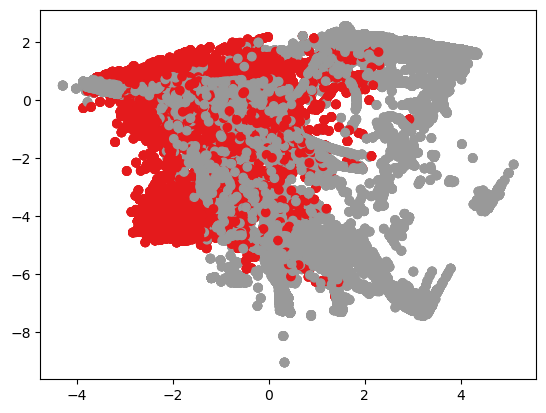

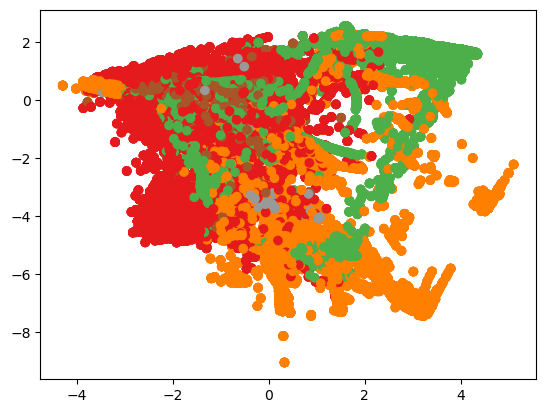

64.54440212249756


In [37]:
t0 = time()
viz_train_data = np.array(pca_train_df.rdd.map(lambda row: [*row['pca_features'], row['labels2_index'], row['labels5_index']]).collect())
plt.figure()
plt.scatter(x=viz_train_data[:,0], y=viz_train_data[:,1], c=viz_train_data[:,2], cmap="Set1")
plt.figure()
plt.scatter(x=viz_train_data[:,0], y=viz_train_data[:,1], c=viz_train_data[:,3], cmap="Set1")
plt.show()
print(time() - t0)

## 8. KMeans clustering with Random Forest Classifiers

The idea of the first approach is to clusterize data into clusters and then train different Random Forest classifiers for each of the clusters. As Random Forest returns probabilities, it is possible to improve detection rate for a new types of attacks by adjusting threshold.

As KMeans cannot truly handle binary/categorical features only numeric features are used for clustarization.

In [38]:
kmeans_prob_col = 'kmeans_rf_prob'
kmeans_pred_col = 'kmeans_rf_pred'

prob_cols.append(kmeans_prob_col)
pred_cols.append(kmeans_pred_col)

In [39]:
# KMeans clustrering
from pyspark.ml.clustering import KMeans

t0 = time()
kmeans_slicer = VectorSlicer(inputCol="indexed_features", outputCol="features", 
                             names=list(set(selectFeaturesByAR(ar_dict, 0.1)).intersection(numeric_cols)))

kmeans = KMeans(k=8, initSteps=25, maxIter=100, featuresCol="features", predictionCol="cluster", seed=seed)

kmeans_pipeline = Pipeline(stages=[kmeans_slicer, kmeans])

kmeans_model = kmeans_pipeline.fit(scaled_train_df)

kmeans_train_df = kmeans_model.transform(scaled_train_df).cache()
kmeans_cv_df = kmeans_model.transform(scaled_cv_df).cache()
kmeans_test_df = kmeans_model.transform(scaled_test_df).cache()

print(f"Time: {time() - t0:.2f}s")

Time: 22.28s


In [40]:
# Function for describing the contents of the clusters 
def getClusterCrosstab(df, clusterCol='cluster'):
    return (df.crosstab(clusterCol, 'labels2')
              .withColumn('count', col('attack') + col('normal'))
              .withColumn(clusterCol + '_labels2', col(clusterCol + '_labels2').cast('int'))
              .sort(col(clusterCol +'_labels2').asc()))

In [41]:
kmeans_crosstab = getClusterCrosstab(kmeans_train_df).cache()
kmeans_crosstab.show(n=30)

+---------------+------+------+------+
|cluster_labels2|attack|normal| count|
+---------------+------+------+------+
|              0| 88264| 15718|103982|
|              1|202935|   733|203668|
|              2| 46526|376404|422930|
|              3|  2303|   386|  2689|
|              4| 14800| 21151| 35951|
|              5|   117|   214|   331|
|              6| 27166|  3764| 30930|
|              7|    24|    15|    39|
+---------------+------+------+------+



Clustres are splitted into two categories. Frist category contains clusters that have both 'attack' and 'normal' connections and have more than 25 connections. For the first category Random Forest classifiers are aplied. Second category contains all other clusters and maps cluster to 'attack' or 'normal' based on majority. All clusters that contains less or equal than 25 connections are treated as outliers and are mapped to 'attack' type.

In [42]:
# Function for splitting clusters
def splitClusters(crosstab):
    exp = ((col('count') > 25) & (col('attack') > 0) & (col('normal') > 0))

    cluster_rf = (crosstab
        .filter(exp).rdd
        .map(lambda row: (int(row['cluster_labels2']), [row['count'], row['attack']/row['count']]))
        .collectAsMap())

    cluster_mapping = (crosstab
        .filter(~exp).rdd
        .map(lambda row: (int(row['cluster_labels2']), 1.0 if (row['count'] <= 25) | (row['normal'] == 0) else 0.0))
        .collectAsMap())
    
    return cluster_rf, cluster_mapping

kmeans_cluster_rf, kmeans_cluster_mapping = splitClusters(kmeans_crosstab)

print(len(kmeans_cluster_rf), len(kmeans_cluster_mapping))
print(kmeans_cluster_mapping)
kmeans_cluster_rf

8 0
{}


{0: [103982, 0.8488392221730684],
 1: [203668, 0.9964010055580651],
 2: [422930, 0.11000874849265836],
 3: [2689, 0.8564522127184827],
 4: [35951, 0.411671441684515],
 5: [331, 0.35347432024169184],
 6: [30930, 0.8783058519236987],
 7: [39, 0.6153846153846154]}

In [43]:
from pyspark.ml.classification import RandomForestClassifier

# This function returns Random Forest models for provided clusters
def getClusterModels(df, cluster_rf):
    cluster_models = {}

    labels_col = 'labels2_cl_index'
    labels2_indexer.setOutputCol(labels_col)

    rf_slicer = VectorSlicer(inputCol="indexed_features", outputCol="rf_features", 
                             names=selectFeaturesByAR(ar_dict, 0.05))

    for cluster in cluster_rf.keys():
        t1 = time()
        rf_classifier = RandomForestClassifier(labelCol=labels_col, featuresCol='rf_features', seed=seed,
                                               numTrees=500, maxDepth=20, featureSubsetStrategy="sqrt")
        
        rf_pipeline = Pipeline(stages=[labels2_indexer, rf_slicer, rf_classifier])
        cluster_models[cluster] = rf_pipeline.fit(df.filter(col('cluster') == cluster))
        print("Finished %g cluster in %g s" % (cluster, time() - t1))
        
    return cluster_models

In [44]:
# This utility function helps to get predictions/probabilities for the new data and return them into one dataframe
def getProbabilities(df, probCol, cluster_mapping, cluster_models):
    pred_df = (sqlContext.createDataFrame([], StructType([
                    StructField('id', LongType(), False),
                    StructField(probCol, DoubleType(), False)])))
    
    udf_map = udf(lambda cluster: cluster_mapping[cluster], DoubleType())
    pred_df = pred_df.union(df.filter(col('cluster').isin(list(cluster_mapping.keys())))
                            .withColumn(probCol, udf_map(col('cluster')))
                            .select('id', probCol))

                                       
    for k in cluster_models.keys():
        maj_label = cluster_models[k].stages[0].labels[0]
        udf_remap_prob = udf(lambda row: float(row[0]) if (maj_label == 'attack') else float(row[1]), DoubleType())

        pred_df = pred_df.union(cluster_models[k]
                         .transform(df.filter(col('cluster') == k))
                         .withColumn(probCol, udf_remap_prob(col('probability')))
                         .select('id', probCol))

    return pred_df

In [45]:
# Training Random Forest classifiers for each of the clusters
t0 = time()
kmeans_cluster_models = getClusterModels(kmeans_train_df, kmeans_cluster_rf)
print(f"Time: {time() - t0:.2f}s")

Finished 0 cluster in 276.375 s
Finished 1 cluster in 149.849 s
Finished 2 cluster in 2010.94 s
Finished 3 cluster in 7.60764 s
Finished 4 cluster in 17.6665 s
Finished 5 cluster in 2.81301 s
Finished 6 cluster in 70.7443 s
Finished 7 cluster in 2.15832 s
Time: 2538.16s


In [46]:
# Getting probabilities for CV data
t0 = time()
res_cv_df = (res_cv_df.drop(kmeans_prob_col)
             .join(getProbabilities(kmeans_cv_df, kmeans_prob_col, kmeans_cluster_mapping, kmeans_cluster_models), 'id')
             .cache())

res_cv_df.limit(5).show()
print(f"Time: {time() - t0:.2f}s")

+---+-------------+-------+-------+------------------+
| id|labels2_index|labels2|labels5|    kmeans_rf_prob|
+---+-------------+-------+-------+------------------+
| 61|          1.0| attack|    DoS|0.9999853006242009|
| 88|          1.0| attack|    DoS|0.9999861372247683|
|115|          1.0| attack|  Probe|0.9994823248760301|
|120|          1.0| attack|    DoS|0.9999845893934297|
|210|          1.0| attack|  Probe| 0.999963959693909|
+---+-------------+-------+-------+------------------+

Time: 148.11s


In [47]:
# Getting probabilities for Test data
t0 = time()
res_test_df = (res_test_df.drop(kmeans_prob_col)
               .join(getProbabilities(kmeans_test_df, kmeans_prob_col, kmeans_cluster_mapping, kmeans_cluster_models), 'id')
               .cache())

print(res_test_df.count())
print(f"Time: {time() - t0:.2f}s")

22544
Time: 162.54s


As CV data is from the same distribution as the train data it isn't needed to adjust threshold.

In [48]:
printReport(res_cv_df, kmeans_prob_col, e=0.5, labels=labels2)

      	normal	attack	
normal	103727	    77	
attack	   280	 95396	
 
Accuracy = 0.99821
AUC = 0.998166
 
False Alarm Rate = 0.000741783
Detection Rate = 0.997073
F1 score = 0.998132
 
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00    103804
      attack       1.00      1.00      1.00     95676

    accuracy                           1.00    199480
   macro avg       1.00      1.00      1.00    199480
weighted avg       1.00      1.00      1.00    199480

 


Because test data is from the different distribution and it is expected to face unseen attack types, it makes sence to adjust a probability threshold to something like 0.01 for attack connections (0.99 for normal connections). For this approach it gives around ~98-99% Detection Rate with around ~14-15% of False Alarm Rate.

In [49]:
printReport(res_test_df, kmeans_prob_col, e=0.01, labels=labels2)

      	normal	attack	
normal	  8384	  1327	
attack	     0	 12833	
 
Accuracy = 0.941137
AUC = 0.931675
 
False Alarm Rate = 0.136649
Detection Rate = 1
F1 score = 0.950839
 
              precision    recall  f1-score   support

      normal       1.00      0.86      0.93      9711
      attack       0.91      1.00      0.95     12833

    accuracy                           0.94     22544
   macro avg       0.95      0.93      0.94     22544
weighted avg       0.95      0.94      0.94     22544

 


In [50]:
# Adding prediction columns based on chosen thresholds into result dataframes
t0 = time()
res_cv_df = res_cv_df.withColumn(kmeans_pred_col, getPrediction(0.5)(col(kmeans_prob_col))).cache()
res_test_df = res_test_df.withColumn(kmeans_pred_col, getPrediction(0.01)(col(kmeans_prob_col))).cache()

print(res_cv_df.count())
print(res_test_df.count())
print(f"Time: {time() - t0:.2f}s")

199480
22544
Time: 308.96s


## 9. Supervised approach for dettecting each type of attacks separately

The idea of the following approach is training Random Forest Classifiers for each of four major 'attack' categories separately.

### 9.1 DoS and normal

In [51]:
dos_prob_col = 'dos_prob'
dos_pred_col = 'dos_pred'

prob_cols.append(dos_prob_col)
pred_cols.append(dos_pred_col)

In [52]:
dos_exp = (col('labels5') == 'DoS') | (col('labels5') == 'normal')
dos_train_df = (scaled_train_df.filter(dos_exp).cache())

print(dos_train_df.count())
(dos_train_df
     .groupby('labels5')
     .count()
     .sort(sql.desc('count'))
     .show())

707026
+-------+------+
|labels5| count|
+-------+------+
| normal|418385|
|    DoS|288641|
+-------+------+



Commented code below is related to undersampling 'normal' connections. It could give better results. However, it hasen't been tested a lot yet.

In [53]:
# dos_train_df = dos_train_df.sampleBy('labels5', fractions={'normal': 45927./67343, 'DoS': 1.0}).cache()

# print(dos_train_df.count())
# (dos_train_df
#      .groupby('labels5')
#      .count()
#      .sort(sql.desc('count'))
#      .show())

Diffirent AR feature selection is used as only normal and DoS connections are treated. Note that train dataframe without standartization is used for getting Attribute Ratio dictionary.

In [54]:
t0 = time()
dos_ar_dict = getAttributeRatio(train_df.filter(dos_exp), numeric_cols, binary_cols, 'labels5')

print(f"Time: {time() - t0:.2f}s")
dos_ar_dict

Time: 11.38s


OrderedDict([('flag_SF', 17.533113287904598),
             ('protocol_type_tcp', 11.026227213650149),
             ('logged_in', 2.507873063642837),
             ('dst_host_srv_serror_rate', 2.4172364226356207),
             ('srv_serror_rate', 2.3907271840723454),
             ('serror_rate', 2.384570171579263),
             ('dst_host_serror_rate', 2.3819850487714893),
             ('wrong_fragment', 2.3709309174034003),
             ('flag_S0', 2.2509436511868834),
             ('count', 2.0416854358670817),
             ('rerror_rate', 1.86978981788291),
             ('srv_rerror_rate', 1.866280153938571),
             ('dst_host_srv_rerror_rate', 1.8546362428589136),
             ('dst_host_rerror_rate', 1.850335258463858),
             ('urgent', 1.6910735385080882),
             ('num_file_creations', 1.6910735385080882),
             ('num_access_files', 1.6910735385080882),
             ('num_failed_logins', 1.691073538508088),
             ('num_root', 1.691073538508088),
   

In [55]:
t0 = time()
dos_slicer = VectorSlicer(inputCol="indexed_features", outputCol="features", 
                          names=selectFeaturesByAR(dos_ar_dict, 0.05))

dos_rf = RandomForestClassifier(labelCol=labels_col, featuresCol='features', featureSubsetStrategy='sqrt',
                                numTrees=500, maxDepth=20, seed=seed)

dos_rf_pipeline = Pipeline(stages=[dos_slicer, dos_rf])
dos_rf_model = dos_rf_pipeline.fit(dos_train_df)

dos_cv_df = dos_rf_model.transform(scaled_cv_df).cache()
dos_test_df = dos_rf_model.transform(scaled_test_df).cache()
print(dos_cv_df.count())
print(dos_test_df.count())

print(f"Time: {time() - t0:.2f}s")

199480
22544
Time: 1968.87s


In [56]:
# Getting probabilities for CV data
t0 = time()
res_cv_df = (res_cv_df.drop(dos_prob_col)
             .join(dos_cv_df.rdd
                    .map(lambda row: (row['id'], float(row['probability'][1])))
                    .toDF(['id', dos_prob_col]),
                    'id')
                    .cache())

print(res_cv_df.count())
print(f"Time: {time() - t0:.2f}s")

199480
Time: 85.16s


In [57]:
# Getting probabilities for Test data
t0 = time()
res_test_df = (res_test_df.drop(dos_prob_col)
               .join(dos_test_df.rdd
                    .map(lambda row: (row['id'], float(row['probability'][1])))
                    .toDF(['id', dos_prob_col]),
                    'id')
                    .cache())

print(res_test_df.count())
print(f"Time: {time() - t0:.2f}s")

22544
Time: 77.06s


The first report shows performance of classification for 'normal' and 'DoS' labels, the second report shows performance for the whole data with adjusted threshold.

In [58]:
printReport(res_cv_df.filter(dos_exp), probCol=dos_prob_col, e=0.5, labels=['normal', 'DoS'])
printReport(res_cv_df, probCol=dos_prob_col, e=0.05)

      	normal	   DoS	
normal	103768	    36	
   DoS	     6	 72224	
 
Accuracy = 0.999761
AUC = 0.999785
 
False Alarm Rate = 0.000346807
Detection Rate = 0.999917
F1 score = 0.999709
 
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00    103804
         DoS       1.00      1.00      1.00     72230

    accuracy                           1.00    176034
   macro avg       1.00      1.00      1.00    176034
weighted avg       1.00      1.00      1.00    176034

 
      	normal	attack	
normal	103402	   402	
attack	  6734	 88942	
 
Accuracy = 0.964227
AUC = 0.962872
 
False Alarm Rate = 0.00387268
Detection Rate = 0.929617
F1 score = 0.961431
 
              precision    recall  f1-score   support

      normal       0.94      1.00      0.97    103804
      attack       1.00      0.93      0.96     95676

    accuracy                           0.96    199480
   macro avg       0.97      0.96      0.96    199480
weighted avg       0.97      0.9

In [59]:
printReport(res_test_df.filter(dos_exp), probCol=dos_prob_col, e=0.5, labels=['normal', 'DoS'])
printReport(res_test_df, probCol=dos_prob_col, e=0.01)

      	normal	   DoS	
normal	  9688	    23	
   DoS	     4	  7454	
 
Accuracy = 0.998427
AUC = 0.998548
 
False Alarm Rate = 0.00236845
Detection Rate = 0.999464
F1 score = 0.998192
 
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      9711
         DoS       1.00      1.00      1.00      7458

    accuracy                           1.00     17169
   macro avg       1.00      1.00      1.00     17169
weighted avg       1.00      1.00      1.00     17169

 
      	normal	attack	
normal	  9475	   236	
attack	  1623	 11210	
 
Accuracy = 0.917539
AUC = 0.924613
 
False Alarm Rate = 0.0243023
Detection Rate = 0.873529
F1 score = 0.923432
 
              precision    recall  f1-score   support

      normal       0.85      0.98      0.91      9711
      attack       0.98      0.87      0.92     12833

    accuracy                           0.92     22544
   macro avg       0.92      0.92      0.92     22544
weighted avg       0.93      0.92 

In [60]:
# Adding prediction columns based on chosen thresholds into result dataframes
t0 = time()
res_cv_df = res_cv_df.withColumn(dos_pred_col, getPrediction(0.05)(col(dos_prob_col))).cache()
res_test_df = res_test_df.withColumn(dos_pred_col, getPrediction(0.01)(col(dos_prob_col))).cache()

print(res_cv_df.count())
print(res_test_df.count())
print(f"Time: {time() - t0:.2f}s")

199480
22544
Time: 14.41s


### 9.2 Probe and normal

In [61]:
probe_prob_col = 'probe_prob'
probe_pred_col = 'probe_pred'

prob_cols.append(probe_prob_col)
pred_cols.append(probe_pred_col)

In [62]:
probe_exp = (col('labels5') == 'Probe') | (col('labels5') == 'normal')
probe_train_df = (scaled_train_df.filter(probe_exp).cache())

print(probe_train_df.count())
(probe_train_df
     .groupby('labels5')
     .count()
     .sort(sql.desc('count'))
     .show())

493567
+-------+------+
|labels5| count|
+-------+------+
| normal|418385|
|  Probe| 75182|
+-------+------+



Commented code below is related to undersampling 'normal' connections. It could give better results. However, it hasen't been tested a lot yet.

In [63]:
# probe_train_df = probe_train_df.sampleBy('labels5', fractions={'normal': 9274./53789, 'Probe': 1.0}).cache()

# print(probe_train_df.count())
# (probe_train_df
#      .groupby('labels5')
#      .count()
#      .sort(sql.desc('count'))
#      .show())

Diffirent AR feature selection is used as only normal and Probe connections are treated. Note that train dataframe without standartization is used for getting Attribute Ratio dictionary.

In [64]:
t0 = time()
probe_ar_dict = getAttributeRatio(train_df.filter(probe_exp), numeric_cols, binary_cols, 'labels5')

print(f"Time: {time() - t0:.2f}s")
probe_ar_dict

Time: 6.43s


OrderedDict([('flag_SF', 17.533113287904598),
             ('dst_bytes', 5.559953377960943),
             ('src_bytes', 5.392511559511882),
             ('duration', 4.419256942612323),
             ('rerror_rate', 4.398786677494481),
             ('srv_rerror_rate', 4.392653395959619),
             ('dst_host_srv_rerror_rate', 4.383663500418284),
             ('diff_srv_rate', 4.347163307501393),
             ('dst_host_diff_srv_rate', 4.281780163976992),
             ('dst_host_rerror_rate', 4.110995110764435),
             ('dst_host_srv_serror_rate', 3.981104251431176),
             ('protocol_type_tcp', 3.9226425588476515),
             ('dst_host_srv_diff_host_rate', 3.6113909049588857),
             ('dst_host_same_src_port_rate', 3.0968648284955322),
             ('srv_serror_rate', 2.947004839935711),
             ('serror_rate', 2.9241693243328015),
             ('dst_host_serror_rate', 2.810377689321423),
             ('count', 2.5388564608594337),
             ('logged_in',

In [65]:
t0 = time()
probe_slicer = VectorSlicer(inputCol="indexed_features", outputCol="features",
                            names=selectFeaturesByAR(probe_ar_dict, 0.05))

probe_rf = RandomForestClassifier(labelCol=labels_col, featuresCol='features', featureSubsetStrategy='sqrt',
                                  numTrees=500, maxDepth=20, seed=seed)
probe_rf_pipeline = Pipeline(stages=[probe_slicer, probe_rf])

probe_rf_model = probe_rf_pipeline.fit(probe_train_df)

probe_cv_df = probe_rf_model.transform(scaled_cv_df).cache()
probe_test_df = probe_rf_model.transform(scaled_test_df).cache()

print(probe_cv_df.count())
print(probe_test_df.count())
print(f"Time: {time() - t0:.2f}s")

199480
22544
Time: 1797.71s


In [66]:
# Getting probabilities for CV data
t0 = time()
res_cv_df = (res_cv_df.drop(probe_prob_col)
             .join(probe_cv_df.rdd
                    .map(lambda row: (row['id'], float(row['probability'][1])))
                    .toDF(['id', probe_prob_col]), 'id')
                    .cache())

print(res_cv_df.count())
print(f"Time: {time() - t0:.2f}s")

199480
Time: 22.44s


In [67]:
# Getting probabilities for Test data
t0 = time()
res_test_df = (res_test_df.drop(probe_prob_col)
               .join(probe_test_df.rdd
                    .map(lambda row: (row['id'], float(row['probability'][1])))
                    .toDF(['id', probe_prob_col]), 'id')
                    .cache())

print(res_test_df.count())
print(f"Time: {time() - t0:.2f}s")

22544
Time: 14.91s


The first report shows performance of classification for 'normal' and 'Probe' labels, the second report shows performance for the whole data with adjusted threshold.

In [68]:
printReport(res_cv_df.filter(probe_exp), probCol=probe_prob_col, e=0.5, labels=['normal', 'Probe'])
printReport(res_cv_df, probCol=probe_prob_col, e=0.05)

      	normal	 Probe	
normal	103768	    36	
 Probe	     5	 18891	
 
Accuracy = 0.999666
AUC = 0.999694
 
False Alarm Rate = 0.000346807
Detection Rate = 0.999735
F1 score = 0.998916
 
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00    103804
       Probe       1.00      1.00      1.00     18896

    accuracy                           1.00    122700
   macro avg       1.00      1.00      1.00    122700
weighted avg       1.00      1.00      1.00    122700

 
      	normal	attack	
normal	102855	   949	
attack	  6866	 88810	
 
Accuracy = 0.960823
AUC = 0.959547
 
False Alarm Rate = 0.00914223
Detection Rate = 0.928237
F1 score = 0.957856
 
              precision    recall  f1-score   support

      normal       0.94      0.99      0.96    103804
      attack       0.99      0.93      0.96     95676

    accuracy                           0.96    199480
   macro avg       0.96      0.96      0.96    199480
weighted avg       0.96      0.9

In [69]:
printReport(res_test_df.filter(probe_exp), probCol=probe_prob_col, e=0.5, labels=['normal', 'Probe'])
printReport(res_test_df, probCol=probe_prob_col, e=0.01)

      	normal	 Probe	
normal	  9696	    15	
 Probe	     0	  2421	
 
Accuracy = 0.998764
AUC = 0.999228
 
False Alarm Rate = 0.00154464
Detection Rate = 1
F1 score = 0.996912
 
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00      9711
       Probe       0.99      1.00      1.00      2421

    accuracy                           1.00     12132
   macro avg       1.00      1.00      1.00     12132
weighted avg       1.00      1.00      1.00     12132

 
      	normal	attack	
normal	  9275	   436	
attack	  1373	 11460	
 
Accuracy = 0.919757
AUC = 0.924056
 
False Alarm Rate = 0.0448975
Detection Rate = 0.89301
F1 score = 0.926847
 
              precision    recall  f1-score   support

      normal       0.87      0.96      0.91      9711
      attack       0.96      0.89      0.93     12833

    accuracy                           0.92     22544
   macro avg       0.92      0.92      0.92     22544
weighted avg       0.92      0.92      0.9

In [70]:
# Adding prediction columns based on chosen thresholds into result dataframes
t0 = time()
res_cv_df = res_cv_df.withColumn(probe_pred_col, getPrediction(0.05)(col(probe_prob_col))).cache()
res_test_df = res_test_df.withColumn(probe_pred_col, getPrediction(0.01)(col(probe_prob_col))).cache()

print(res_cv_df.count())
print(res_test_df.count())
print(f"Time: {time() - t0:.2f}s")

199480
22544
Time: 18.10s


### 9.3 R2L, U2R and normal types

As there are a few examples of both R2L and U2R attack types and they have similar behaviour, they are combined into one group.

In [71]:
r2l_u2r_prob_col = 'r2l_u2r_prob'
r2l_u2r_pred_col = 'r2l_u2r_pred'

prob_cols.append(r2l_u2r_prob_col)
pred_cols.append(r2l_u2r_pred_col)

In [72]:
r2l_u2r_exp = (col('labels5') == 'R2L') | (col('labels5') == 'U2R') | (col('labels5') == 'normal')
r2l_u2r_train_df = (scaled_train_df.filter(r2l_u2r_exp).cache())

print(r2l_u2r_train_df.count())
(r2l_u2r_train_df
     .groupby('labels5')
     .count()
     .sort(sql.desc('count'))
     .show())

436697
+-------+------+
|labels5| count|
+-------+------+
| normal|418385|
|    R2L| 17185|
|    U2R|  1127|
+-------+------+



Diffirent AR feature selection is used as only normal, R2L and U2R connections are treated. Note that train dataframe without standartization is used for getting Attribute Ratio dictionary.

In [73]:
t0 = time()
r2l_u2r_ar_dict = getAttributeRatio(train_df.filter(r2l_u2r_exp), numeric_cols, binary_cols, 'labels5')

print(f"Time: {time() - t0:.2f}s")
r2l_u2r_ar_dict

Time: 7.50s


OrderedDict([('urgent', 198.47445706430122),
             ('num_shells', 128.37175376268416),
             ('protocol_type_tcp', 60.78260869565217),
             ('flag_SF', 32.139103554868626),
             ('num_file_creations', 21.453997198316504),
             ('num_failed_logins', 20.339610125838934),
             ('dst_host_srv_rerror_rate', 10.262681979588141),
             ('srv_rerror_rate', 10.157434689435155),
             ('rerror_rate', 9.454817501658026),
             ('hot', 9.177269783480345),
             ('src_bytes', 8.251305984251255),
             ('num_access_files', 6.235351847550639),
             ('dst_bytes', 5.568148983137603),
             ('num_compromised', 5.15625402880592),
             ('num_root', 4.597379393838756),
             ('dst_host_srv_serror_rate', 3.0953349617478696),
             ('diff_srv_rate', 2.7922916211978905),
             ('logged_in', 2.507873063642837),
             ('dst_host_same_src_port_rate', 2.305248668636645),
            

In [74]:
t0 = time()
r2l_u2r_slicer = VectorSlicer(inputCol="indexed_features", outputCol="features",
                              names=selectFeaturesByAR(r2l_u2r_ar_dict, 0.05))

r2l_u2r_rf = RandomForestClassifier(labelCol=labels_col, featuresCol='features', featureSubsetStrategy='sqrt',
                                    numTrees=500, maxDepth=20, seed=seed)
r2l_u2r_rf_pipeline = Pipeline(stages=[r2l_u2r_slicer, r2l_u2r_rf])

r2l_u2r_rf_model = r2l_u2r_rf_pipeline.fit(r2l_u2r_train_df)

r2l_u2r_cv_df = r2l_u2r_rf_model.transform(scaled_cv_df).cache()
r2l_u2r_test_df = r2l_u2r_rf_model.transform(scaled_test_df).cache()
print(r2l_u2r_cv_df.count())
print(r2l_u2r_test_df.count())

print(f"Time: {time() - t0:.2f}s")

199480
22544
Time: 1848.22s


In [75]:
# Getting probabilities for CV data
t0 = time()
res_cv_df = (res_cv_df.drop(r2l_u2r_prob_col)
             .join(r2l_u2r_cv_df.rdd
                    .map(lambda row: (row['id'], float(row['probability'][1])))
                    .toDF(['id', r2l_u2r_prob_col]), 'id')
                    .cache())

print(res_cv_df.count())
print(f"Time: {time() - t0:.2f}s")

199480
Time: 26.96s


In [76]:
# Getting probabilities for Test data
t0 = time()
res_test_df = (res_test_df.drop(r2l_u2r_prob_col)
               .join(r2l_u2r_test_df.rdd
                    .map(lambda row: (row['id'], float(row['probability'][1])))
                    .toDF(['id', r2l_u2r_prob_col]), 'id')
                    .cache())

print(res_test_df.count())
print(f"Time: {time() - t0:.2f}s")

22544
Time: 21.82s


The first report shows performance of classification for 'normal' and 'R2L&U2R' labels, the second report shows performance for the whole data with adjusted threshold.

In [77]:
printReport(res_cv_df.filter(r2l_u2r_exp), probCol=r2l_u2r_prob_col, e=0.5, labels=['normal', 'R2L&U2R'])
printReport(res_cv_df, probCol=r2l_u2r_prob_col, e=0.05, labels=labels2)

       	 normal	R2L&U2R	
 normal	 103794	     10	
R2L&U2R	    258	   4292	
 
Accuracy = 0.997527
AUC = 0.9716
 
False Alarm Rate = 9.63354e-05
Detection Rate = 0.943297
F1 score = 0.969724
 
              precision    recall  f1-score   support

      normal       1.00      1.00      1.00    103804
     R2L&U2R       1.00      0.94      0.97      4550

    accuracy                           1.00    108354
   macro avg       1.00      0.97      0.98    108354
weighted avg       1.00      1.00      1.00    108354

 
      	normal	attack	
normal	102621	  1183	
attack	 19974	 75702	
 
Accuracy = 0.893939
AUC = 0.889918
 
False Alarm Rate = 0.0113965
Detection Rate = 0.791233
F1 score = 0.877394
 
              precision    recall  f1-score   support

      normal       0.84      0.99      0.91    103804
      attack       0.98      0.79      0.88     95676

    accuracy                           0.89    199480
   macro avg       0.91      0.89      0.89    199480
weighted avg       0.91   

In [78]:
printReport(res_test_df.filter(r2l_u2r_exp), probCol=r2l_u2r_prob_col, e=0.5, labels=['normal', 'R2L&U2R'])
printReport(res_test_df, probCol=r2l_u2r_prob_col, e=0.01, labels=labels2)

       	 normal	R2L&U2R	
 normal	   9710	      1	
R2L&U2R	    218	   2736	
 
Accuracy = 0.982708
AUC = 0.963049
 
False Alarm Rate = 0.000102976
Detection Rate = 0.926202
F1 score = 0.961518
 
              precision    recall  f1-score   support

      normal       0.98      1.00      0.99      9711
     R2L&U2R       1.00      0.93      0.96      2954

    accuracy                           0.98     12665
   macro avg       0.99      0.96      0.98     12665
weighted avg       0.98      0.98      0.98     12665

 
      	normal	attack	
normal	  8679	  1032	
attack	   486	 12347	
 
Accuracy = 0.932665
AUC = 0.927929
 
False Alarm Rate = 0.106271
Detection Rate = 0.962129
F1 score = 0.942088
 
              precision    recall  f1-score   support

      normal       0.95      0.89      0.92      9711
      attack       0.92      0.96      0.94     12833

    accuracy                           0.93     22544
   macro avg       0.93      0.93      0.93     22544
weighted avg       0.93  

In [79]:
# Adding prediction columns based on chosen thresholds into result dataframes
t0 = time()
res_cv_df = res_cv_df.withColumn(r2l_u2r_pred_col, getPrediction(0.05)(col(r2l_u2r_prob_col))).cache()
res_test_df = res_test_df.withColumn(r2l_u2r_pred_col, getPrediction(0.01)(col(r2l_u2r_prob_col))).cache()

print(res_cv_df.count())
print(res_test_df.count())
print(f"Time: {time() - t0:.2f}s")

199480
22544
Time: 36.87s


### 9.4 Combining results

In [80]:
sup_prob_col = 'sup_prob'
sup_pred_col = 'sup_pred'

prob_cols.append(sup_prob_col)
pred_cols.append(sup_pred_col)

In [81]:
res_cv_df = res_cv_df.withColumn(sup_prob_col, 
                                 (col(dos_prob_col) + col(probe_prob_col) + col(r2l_u2r_prob_col))/3).cache()

printReport(res_cv_df, sup_prob_col, e=0.05, labels=labels2)

      	normal	attack	
normal	102720	  1084	
attack	    19	 95657	
 
Accuracy = 0.994471
AUC = 0.994679
 
False Alarm Rate = 0.0104428
Detection Rate = 0.999801
F1 score = 0.994268
 
              precision    recall  f1-score   support

      normal       1.00      0.99      0.99    103804
      attack       0.99      1.00      0.99     95676

    accuracy                           0.99    199480
   macro avg       0.99      0.99      0.99    199480
weighted avg       0.99      0.99      0.99    199480

 


In [82]:
res_cv_df = res_cv_df.withColumn(sup_pred_col, col(dos_pred_col).cast('int')
                                        .bitwiseOR(col(probe_pred_col).cast('int'))
                                        .bitwiseOR(col(r2l_u2r_pred_col).cast('int'))).cache()

printReport(res_cv_df, sup_pred_col, labels=labels2)

      	normal	attack	
normal	101519	  2285	
attack	     1	 95675	
 
Accuracy = 0.98854
AUC = 0.988988
 
False Alarm Rate = 0.0220126
Detection Rate = 0.99999
F1 score = 0.988194
 
              precision    recall  f1-score   support

      normal       1.00      0.98      0.99    103804
      attack       0.98      1.00      0.99     95676

    accuracy                           0.99    199480
   macro avg       0.99      0.99      0.99    199480
weighted avg       0.99      0.99      0.99    199480

 


In [83]:
res_test_df = res_test_df.withColumn(sup_prob_col, 
                                 (col(dos_prob_col) + col(probe_prob_col) + col(r2l_u2r_prob_col))/3).cache()

printReport(res_test_df, sup_prob_col, e=0.005, labels=labels2)

      	normal	attack	
normal	  8450	  1261	
attack	     0	 12833	
 
Accuracy = 0.944065
AUC = 0.935074
 
False Alarm Rate = 0.129853
Detection Rate = 1
F1 score = 0.95317
 
              precision    recall  f1-score   support

      normal       1.00      0.87      0.93      9711
      attack       0.91      1.00      0.95     12833

    accuracy                           0.94     22544
   macro avg       0.96      0.94      0.94     22544
weighted avg       0.95      0.94      0.94     22544

 


In [84]:
res_test_df = res_test_df.withColumn(sup_pred_col, col(dos_pred_col).cast('int')
                                            .bitwiseOR(col(probe_pred_col).cast('int'))
                                            .bitwiseOR(col(r2l_u2r_pred_col).cast('int'))).cache()

printReport(res_test_df, sup_pred_col, labels=labels2)

      	normal	attack	
normal	  8378	  1333	
attack	     0	 12833	
 
Accuracy = 0.940871
AUC = 0.931366
 
False Alarm Rate = 0.137267
Detection Rate = 1
F1 score = 0.950628
 
              precision    recall  f1-score   support

      normal       1.00      0.86      0.93      9711
      attack       0.91      1.00      0.95     12833

    accuracy                           0.94     22544
   macro avg       0.95      0.93      0.94     22544
weighted avg       0.95      0.94      0.94     22544

 


## 10. Results summary



The best result was achieved using KMeans Clustering combined with Random Forest Classifiers.  
This approach provides approximately 98–99% detection rate with a reasonable 14–15% false alarm rate.  
The F1 score obtained is around 0.94, with a weighted F1 score of 0.93.  

This demonstrates that combining anomaly detection (KMeans) with classification (Random Forest) is effective for identifying cyber attacks in network traffic.  
Most of the attack connections, including previously unseen ones, are successfully detected, with only a small number of attacks remaining unrecognized.